In [18]:
import pandas as pd
import numpy as np
quarters_df = pd.read_csv('nba_quarters_2324.csv')

# Supprimer les lignes avec NaN (OT, données manquantes)
df_clean = quarters_df.dropna(subset=['Q1','Q2','Q3','Q4']).copy()
df_clean = df_clean[(df_clean[['Q1','Q2','Q3','Q4']] > 0).all(axis=1)]

print(f"Matchs utilisables : {len(df_clean)}")

# Target : score final = Q1+Q2+Q3+Q4
df_clean['FINAL'] = df_clean['Q1'] + df_clean['Q2'] + df_clean['Q3'] + df_clean['Q4']

print(f"\nStats descriptives :")
print(df_clean[['Q1','Q2','Q3','Q4','FINAL']].describe().round(1))

Matchs utilisables : 400

Stats descriptives :
          Q1     Q2     Q3     Q4  FINAL
count  400.0  400.0  400.0  400.0  400.0
mean    28.4   28.3   28.6   27.8  113.1
std      5.8    6.0    6.0    5.8   11.9
min     12.0   12.0   12.0   11.0   83.0
25%     25.0   24.0   24.0   24.0  105.0
50%     28.0   28.0   28.0   28.0  113.0
75%     32.2   33.0   33.0   32.0  121.0
max     44.0   47.0   50.0   46.0  155.0


In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Input : [Q1, Q2, Q3] par équipe → shape (n, 3, 1)
# On ajoute le score cumulé comme 2e feature pour enrichir le signal
df_clean['CUM2'] = df_clean['Q1'] + df_clean['Q2']
df_clean['CUM3'] = df_clean['CUM2'] + df_clean['Q3']


In [20]:
df_clean

,game_id,team,Q1,Q2,Q3,Q4,FINAL,CUM2,CUM3
0,22300061,DEN,34,29,24,32,119,63,87
1,22300061,LAL,20,34,26,27,107,54,80
2,22300062,GSW,28,18,40,18,104,46,86
3,22300062,PHX,28,33,19,28,108,61,80
4,22300071,MEM,28,19,23,34,104,47,70
...,...,...,...,...,...,...,...,...,...
395,22300219,MIL,31,39,34,38,142,70,104
396,22300221,MIN,31,27,35,24,117,58,93
397,22300221,NYK,28,28,19,25,100,56,75
398,22300223,SAS,27,28,22,22,99,55,77


In [21]:
X_raw = df_clean[['Q1','Q2','Q3','CUM2','CUM3']].values

X = np.stack([
    np.hstack([df_clean[['Q1']], df_clean[['Q1']]]),     # Q1 → cumul = Q1
    np.hstack([df_clean[['Q2']], df_clean[['CUM2']]]),   # Q2 → cumul = Q1+Q2
    np.hstack([df_clean[['Q3']], df_clean[['CUM3']]]),   # Q3 → cumul = Q1+Q2+Q3
], axis=1)

In [22]:
y = df_clean['FINAL'].values

print(f"X shape: {X.shape}")  # (n, 3, 1)
print(f"y shape: {y.shape}")

X shape: (400, 3, 2)
y shape: (400,)


In [23]:
# Normalisation
scaler_X = MinMaxScaler()
X_2d = X.reshape(-1, 1)
X_scaled = scaler_X.fit_transform(X_2d).reshape(X.shape)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (320, 3, 2) | Test: (80, 3, 2)


In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(3, 2)), # Changed input_shape from (3, 1) to (3, 2)
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 3, 64)          │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop = EarlyStopping(patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.1212 - mae: 0.3035 - val_loss: 0.0565 - val_mae: 0.1946
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0276 - mae: 0.1375 - val_loss: 0.0223 - val_mae: 0.1185
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0231 - mae: 0.1191 - val_loss: 0.0264 - val_mae: 0.1268
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0215 - mae: 0.1209 - val_loss: 0.0212 - val_mae: 0.1126
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0199 - mae: 0.1163 - val_loss: 0.0219 - val_mae: 0.1135
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0203 - mae: 0.1151 - val_loss: 0.0206 - val_mae: 0.1106
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0174 - mae: 0.1090 - val_loss: 0.0191 - val_mae: 0.1072
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0172 - mae: 0.1063 - val_loss: 0.0182 - val_mae: 0.1058
Epoch 9/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 508ms/step


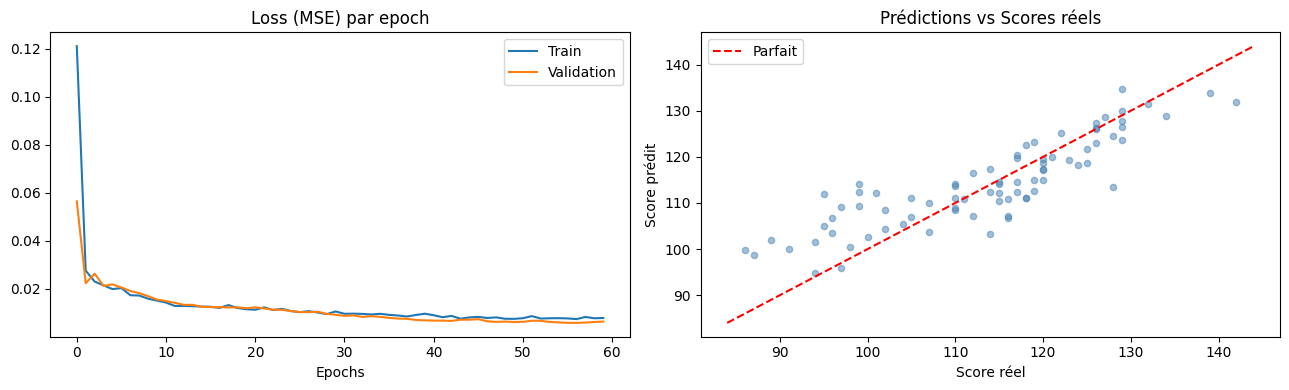


📊 MAE : 5.1 points  (erreur moyenne sur le score final)
📊 Min score réel : 86  |  Max : 142


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss (MSE) par epoch')
axes[0].set_xlabel('Epochs')
axes[0].legend()

# Prédictions vs Réel
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s).flatten()
y_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

axes[1].scatter(y_real, y_pred, alpha=0.5, color='steelblue', s=20)
lims = [y_real.min()-2, y_real.max()+2]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Parfait')
axes[1].set_xlabel('Score réel')
axes[1].set_ylabel('Score prédit')
axes[1].set_title('Prédictions vs Scores réels')
axes[1].legend()

plt.tight_layout()
plt.show()

mae = np.mean(np.abs(y_pred - y_real))
print(f"\n📊 MAE : {mae:.1f} points  (erreur moyenne sur le score final)")
print(f"📊 Min score réel : {y_real.min():.0f}  |  Max : {y_real.max():.0f}")

In [29]:
# Prends une équipe au hasard dans le test set et compare
idx = np.random.randint(0, len(X_test))

x_sample = X_test[idx:idx+1]  # shape (1, 3, 1)
pred_s = model.predict(x_sample)
pred = scaler_y.inverse_transform(pred_s)[0][0]
real = y_real[idx]

# Recalcule les quarts réels
q_values = scaler_X.inverse_transform(X_test[idx].reshape(-1,1)).flatten()

print(f"Q1: {q_values[0]:.0f} pts | Q2: {q_values[1]:.0f} pts | Q3: {q_values[2]:.0f} pts")
print(f"Score final réel   : {real:.0f} pts")
print(f"Score final prédit : {pred:.0f} pts")
print(f"Écart              : {abs(pred - real):.0f} pts")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Q1: 27 pts | Q2: 27 pts | Q3: 29 pts
Score final réel   : 107 pts
Score final prédit : 110 pts
Écart              : 3 pts
